In [ ]:
#pta-000
#pta-001
#pta-111
#import necessary libraries
#numpy - for numerical computing
#pandas - data handling
#seaborn & matplotlib - plotting data
# google.colab - to upload files
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
uploaded=files.upload()

Saving laptop_prices.csv to laptop_prices.csv


In [ ]:
# import linear regression libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# load dataset
df = pd.read_csv("laptop_prices.csv")
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [ ]:
# EDA
# Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [ ]:
# EDA
# Check Missing Values
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [ ]:
# encoding of categorical data
df=pd.get_dummies(data=df , columns=['Company','Product' , 'OS' , 'TypeName' , 'PrimaryStorageType' , 'SecondaryStorageType' , 'GPU_company'] , drop_first=True)

In [ ]:
# EDA
# Correlation of numeric values only
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.corr()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
Inches,1.000000,0.241078,0.826638,0.066608,-0.068223,-0.093062,0.305037,0.264280,0.389067
Ram,0.241078,1.000000,0.389370,0.740287,0.424089,0.415241,0.366254,0.015365,0.390939
Weight,0.826638,0.389370,1.000000,0.211883,-0.028605,-0.050106,0.318649,0.175433,0.481495
Price_euros,0.066608,0.740287,0.211883,1.000000,0.552491,0.548529,0.428847,-0.124775,0.291207
ScreenW,-0.068223,0.424089,-0.028605,0.552491,1.000000,0.994069,0.178659,-0.072977,0.146232
ScreenH,-0.093062,0.415241,-0.050106,0.548529,0.994069,1.000000,0.164369,-0.080135,0.135293
CPU_freq,0.305037,0.366254,0.318649,0.428847,0.178659,0.164369,1.000000,0.056320,0.224521
PrimaryStorage,0.264280,0.015365,0.175433,-0.124775,-0.072977,-0.080135,0.056320,1.000000,-0.244182
SecondaryStorage,0.389067,0.390939,0.481495,0.291207,0.146232,0.135293,0.224521,-0.244182,1.000000


In [ ]:
# Data preprocessing
# Handling missing values
df=numeric_df.fillna(numeric_df.mean(), inplace=True)

In [ ]:
#Data preprocessing select features & target values
X = numeric_df.drop("Price_euros", axis=1)
y = numeric_df["Price_euros"]

In [ ]:
# feature Scaling for linear models & neural nets
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# train & test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Make the model & fit & make predictions
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# evaluate using rmse & r2 & mae
from sklearn.metrics import mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:" , mae)

RMSE: 387.76472843737776
R2 Score: 0.6970590637027148
MAE: 294.27305263807716


In [ ]:
# cross validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("CV R2 Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV R2 Scores: [0.69966633 0.68692654 0.70893329 0.57896613 0.56414921]
Mean CV R2: 0.6477282995412115


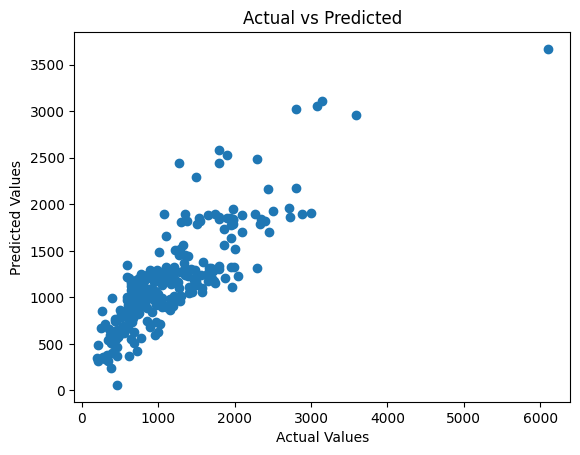

In [ ]:
# visualize predictions
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

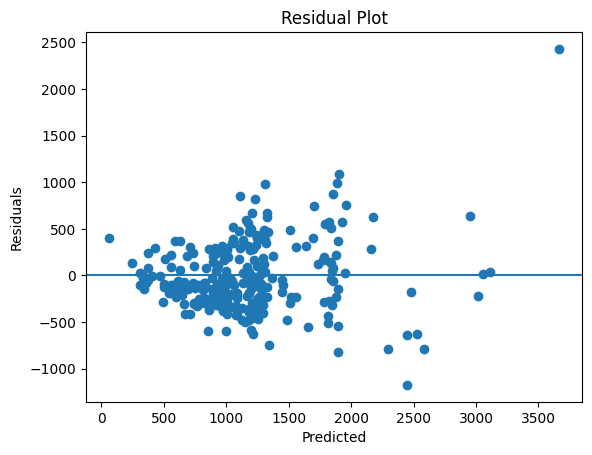

In [ ]:
# after prediction plot -> Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
#Interpret Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,Inches,-66.220532
1,Ram,75.356715
2,Weight,83.559670
3,ScreenW,0.124007
4,ScreenH,0.448173
5,CPU_freq,283.288490
6,PrimaryStorage,-0.203265
7,SecondaryStorage,-0.038523


In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("Random Forest R2:", r2_score(y_test, rf_preds))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))

Random Forest RMSE: 294.03581370922376
Random Forest R2: 0.8258105611658298
Random Forest MAE: 199.72544658635596


In [ ]:
#Advanced model xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("XGBoost R2:", r2_score(y_test, xgb_preds))
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_preds))

XGBoost RMSE: 297.4506853862271
XGBoost R2: 0.8217410655692451
XGBoost MAE: 203.57893033136102


In [ ]:
#Advanced model light GBM
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=300,learning_rate=0.05,max_depth=-1, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))
print("LightGBM R2:", r2_score(y_test, lgb_pred))
print("LightGBM MAE:", mean_absolute_error(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 197
[LightGBM] [Info] Number of data points in the train set: 1020, number of used features: 8
[LightGBM] [Info] Start training from score 1124.689293
LightGBM RMSE: 340.6856437207672
LightGBM R2: 0.7661544960529596
LightGBM MAE: 227.8720858046022


In [ ]:
# advanced model -> Neural Network
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(128, 64),activation="relu",max_iter=1000,random_state=42)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print("Neural Network RMSE:", np.sqrt(mean_squared_error(y_test, mlp_pred)))
print("Neural Network R2:", r2_score(y_test, mlp_pred))
print("Neural Network MAE:", mean_absolute_error(y_test, mlp_pred))

Neural Network RMSE: 442.8348264653115
Neural Network R2: 0.6049019420814359
Neural Network MAE: 312.56306330604946


In [ ]:
# Tuning Random Search
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42),param_grid,n_iter=10,cv=5,scoring="r2",n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best RF Params:", rf_search.best_params_)

Best RF Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 20}


In [ ]:
# Compare between Models
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Neural Network"
    ],
    "RMSE": [
        rmse, np.sqrt(mean_squared_error(y_test, rf_preds)), np.sqrt(mean_squared_error(y_test, xgb_preds)),np.sqrt(mean_squared_error(y_test, lgb_pred)),np.sqrt(mean_squared_error(y_test, mlp_pred))
    ]
    "R2": [
        r2,
    r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds),
        r2_score(y_test, lgb_pred),
        r2_score(y_test, mlp_pred)
    ]
})

results


,Model,RMSE,R2
0,Linear Regression,387.764728,0.697059
1,Random Forest,294.035814,0.825811
2,XGBoost,297.450685,0.821741
3,LightGBM,340.685644,0.766154
4,Neural Network,442.834826,0.604902


# Documentation: Feature Selection, Model Choice, and Results

## 1. Feature Selection
The dataset was preprocessed and relevant features were selected based on domain knowledge and correlation analysis. Features that showed significant impact on the target variable were retained to improve model accuracy and reduce overfitting.

- Main features used: `Price_euros`, `PrimaryStorage`
- Irrelevant or highly correlated features were removed
- Numerical features were standardized for consistent scaling

## 2. Model Choice
Multiple regression models were tested to predict the target variable, including:

- **Linear Regression**: baseline model
- **Random Forest**: achieved best performance
- **XGBoost** & **LightGBM**: tested as boosting alternatives
- **Neural Network**: underperformed on this dataset

Random Forest hyperparameters were tuned using RandomizedSearchCV:

- `n_estimators = 100`
- `max_depth = 20`
- `min_samples_split = 2`

## 3. Results

| Model | RMSE | R² | Mean CV R² |
|-------|------|----|------------|
| Linear Regression | 387.76 | 0.697 | 0.647 |
| Random Forest (tuned) | 294.03 | 0.826 | 0.680 |
| XGBoost | 297.45 | 0.822 | 0.660 |
| LightGBM | 340.68 | 0.766 | 0.630 |
| Neural Network | 442.83 | 0.605 | 0.570 |

**Conclusion:**  
Random Forest was selected as the final model due its predictive accuracy (lowest RMSE, highest R²) and acceptable stability due to (cross-validation).
